# Workshop Final — Machine Learning Integrado
**Equipo Ethos** · Máster en Business Analytics e IA (INESDI)

> **📝 Nota de revisión (versión corregida)**
>
> Cambios principales respecto a la entrega anterior:
> - **El notebook ahora se ejecuta de principio a fin** (*Restart & Run all*). Antes fallaban 3 celdas (`corr` no definido, `KeyError 'mes'`, `NameError 'rf'`) y había celdas que dependían de código borrado (las columnas one-hot).
> - **El target de clasificación ahora encaja con la pregunta de negocio:** `Profit < 0` (pedido con pérdida). Antes se usaba "margen > mediana".
> - **Apartados que estaban vacíos, ya completos:** duplicados, encoding y escalado (1.1.5), conclusiones del EDA (1.1.7), gráficas de matriz de confusión y ROC comparativa, métricas de los modelos de la Fase 2 y evaluación del GridSearch.
> - **Escalado sin fuga de información:** ahora va dentro de `Pipeline` y se ajusta solo con los datos de train.
> - **Clustering a nivel cliente** (793 clientes): k elegido con codo y silueta, y segmentos con nombre según su perfil real.
> - **Interpretaciones corregidas:** MAE, ROC-AUC y la elección entre modelos.

## Contexto y objetivo

Este workshop plantea un **caso de negocio en retail**: una cadena de tiendas quiere entender mejor a sus clientes y optimizar sus decisiones comerciales. Para ello se pondrá en práctica todo el ciclo de Machine Learning.

**Dataset propuesto (opcional):** [Sample - Superstore (Kaggle)](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final)

[Dataset en GitHub (no requiere autenticación)](https://raw.githubusercontent.com/dtoralg/INESDI_Data-Science_ML_IA/main/%5B00%5D%20-%20Workshops/Sample%20-%20Superstore.csv)

- 9994 filas de datos de pedidos de una cadena de tiendas. Encoding latin1.
- Permite trabajar con problemas de **clasificación** (ej. clientes rentables vs. no rentables), **regresión** (predicción de ventas o beneficio) y **clustering** (segmentación de clientes).

**Columnas principales:**
- Order ID / Customer ID: identificadores únicos de pedido y cliente
- Order Date / Ship Mode: fecha y modo de envío
- Segment: tipo de cliente (Consumer, Corporate, Home Office)
- Region / State / City: localización geográfica
- Category / Sub-Category: categoría de producto
- Sales: importe de la venta
- Quantity: número de unidades vendidas
- Discount: descuento aplicado (%)
- Profit: beneficio asociado al pedido

**Problema de negocio (ejemplo):**
“Queremos identificar qué clientes tienen mayor probabilidad de generar pérdidas, predecir su volumen de compra y segmentarlos para diseñar campañas de marketing más eficaces.”

**Importante:**
- Este dataset es una **base común** para quienes lo deseen.
- Cada grupo puede elegir **otro dataset** que cumpla las reglas (mínimo 1000 filas, target definido, datos tabulares) y adaptar el resto del workshop a su caso.

## Pregunta de negocio

**¿Qué pedidos y clientes generan pérdidas, cuánto beneficio podemos esperar de cada venta y qué segmentos de clientes existen para diseñar acciones comerciales diferenciadas?**

Cada parte de la pregunta se resuelve con una técnica distinta:

| Sub-pregunta | Técnica | Target / unidad |
|---|---|---|
| ¿Este pedido va a generar pérdida? | Clasificación (Fase 1.2) | `perdida = Profit < 0` · línea de pedido |
| ¿Cuánto beneficio dejará esta venta? | Regresión (Fases 1.3 y 2) | `Profit` · línea de pedido |
| ¿Qué tipos de cliente tenemos? | PCA + KMeans (Fase 1.4) | sin target · cliente |

# Fase 1 - EDA y primeros modelos

In [1]:
# ==========================================================
# IMPORTS — todas las librerías del notebook en un único sitio
# (en Colab xgboost y shap vienen instalados; si no: !pip install xgboost shap)
# ==========================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, mean_absolute_error, mean_squared_error,
                             r2_score, silhouette_score)

from xgboost import XGBRegressor, plot_importance
import shap

sns.set(style='whitegrid')
pd.set_option('display.max_columns', 40)
RANDOM_STATE = 42

In [2]:
URL = 'https://raw.githubusercontent.com/dtoralg/INESDI_Data-Science_ML_IA/main/%5B00%5D%20-%20Workshops/Sample%20-%20Superstore.csv'
df_raw = pd.read_csv(URL, encoding='latin1')
df_raw.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Fase 1.1: EDA y preparación de datos

1. Descripción del dataset y justificación de su elección
2. Identificación de variables, tipos, nulos y duplicados
3. Limpieza de datos
4. Creación de nuevas variables (feature engineering)
5. Transformaciones: encoding y escalado
6. Gráficos de exploración (distribuciones, correlaciones, top-K, boxplots)
7. Explicaciones y decisiones en función de los resultados (punto de vista de negocio)
------------------------------------------------------------

### 1.1.1 Descripción y justificación

El dataset *Sample - Superstore* recoge **9.994 líneas de pedido** de una cadena minorista de Estados Unidos entre 2014 y 2017. La cadena vende tres categorías: material de oficina, mobiliario y tecnología. Cada fila es **un producto dentro de un pedido**: tiene su importe (`Sales`), unidades, descuento y el beneficio que deja (`Profit`), además de datos del cliente, del envío y de la ubicación.

Lo elegimos porque:
- Responde a un problema real de negocio: muchas ventas no se traducen en beneficio, y la política de descuentos puede destruir margen.
- Permite plantear los tres tipos de problema que pide el workshop: clasificación (¿pérdida?), regresión (¿cuánto beneficio?) y segmentación (¿qué clientes?).
- Cumple los requisitos: más de 1.000 filas, datos tabulares y targets bien definidos.

### 1.1.2 Identificación de variables, tipos, nulos y duplicados

In [3]:
print('Dimensiones:', df_raw.shape)
print('\nTipos de datos:')
print(df_raw.dtypes)

Dimensiones: (9994, 21)

Tipos de datos:
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [4]:
resumen = pd.DataFrame({
    'tipo': df_raw.dtypes.astype(str),
    'nulos': df_raw.isna().sum(),
    'valores_unicos': df_raw.nunique()
})
print(resumen)
print('\nFilas duplicadas (todas las columnas):', df_raw.duplicated().sum())
print('Filas duplicadas (ignorando Row ID):  ', df_raw.drop(columns='Row ID').duplicated().sum())

                  tipo  nulos  valores_unicos
Row ID           int64      0            9994
Order ID           str      0            5009
Order Date         str      0            1237
Ship Date          str      0            1334
Ship Mode          str      0               4
Customer ID        str      0             793
Customer Name      str      0             793
Segment            str      0               3
Country            str      0               1
City               str      0             531
State              str      0              49
Postal Code      int64      0             631
Region             str      0               4
Product ID         str      0            1862
Category           str      0               3
Sub-Category       str      0              17
Product Name       str      0            1850
Sales          float64      0            5825
Quantity         int64      0              14
Discount       float64      0              12
Profit         float64      0     

In [5]:
df_raw[['Sales', 'Quantity', 'Discount', 'Profit']].describe().round(2)

,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,3.79,0.16,28.66
std,623.25,2.23,0.21,234.26
min,0.44,1.00,0.00,-6599.98
25%,17.28,2.00,0.00,1.73
50%,54.49,3.00,0.20,8.67
75%,209.94,5.00,0.20,29.36
max,22638.48,14.00,0.80,8399.98


**Lectura:**
- **9.994 filas × 21 columnas**: 4 numéricas de negocio (`Sales`, `Quantity`, `Discount`, `Profit`), 2 fechas que vienen como texto y el resto categóricas o identificadores.
- **No hay valores nulos** en ninguna columna, así que no hace falta imputar.
- Hay **1 fila duplicada** si se ignora `Row ID`: es la misma línea de pedido registrada dos veces. La eliminamos.
- `Country` tiene un solo valor, así que no aporta información. `City` (531 valores) y `Postal Code` (631) tienen una cardinalidad demasiado alta para hacer one-hot.
- `Profit` es muy asimétrico: la mediana es 8,7 $, pero va de −6.600 $ a +8.400 $. Habrá que tenerlo en cuenta al elegir métricas.

### 1.1.3 Limpieza de datos

In [6]:
df = df_raw.copy()

# 1) Duplicado exacto (misma línea de pedido registrada dos veces)
df = df.drop(columns='Row ID').drop_duplicates().reset_index(drop=True)

# 2) Fechas a datetime con formato explícito (mes/día/año)
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  format='%m/%d/%Y')

# 3) Columnas sin valor predictivo:
#    - Country: constante (solo United States)
#    - Postal Code / City: alta cardinalidad (≈630 / 531 valores) -> la geografía se recoge con Region
#    - Customer Name / Product Name / Product ID: identificadores o texto libre
#    Order ID y Customer ID se CONSERVAN: los necesitamos para agregar a nivel cliente (Fase 1.4)
df = df.drop(columns=['Country', 'Postal Code', 'City', 'Customer Name', 'Product Name', 'Product ID'])

# 4) Comprobaciones de coherencia
assert (df['Quantity'] > 0).all()
assert df['Discount'].between(0, 1).all()
assert (df['Ship Date'] >= df['Order Date']).all()

print('Dimensiones tras la limpieza:', df.shape)
df.head()

Dimensiones tras la limpieza: (9993, 14)


,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,State,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Consumer,Kentucky,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Consumer,Kentucky,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Corporate,California,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Consumer,Florida,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Consumer,Florida,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


**Decisiones de limpieza:**
- Eliminamos el duplicado y las columnas que no aportan nada (constantes, identificadores, texto libre o alta cardinalidad).
- Para la geografía nos quedamos con `Region` en los modelos. `State` se conserva solo para el EDA.
- **Conservamos `Order ID` y `Customer ID`:** no son predictores, pero los necesitamos para agregar los datos por cliente en la segmentación.
- Las fechas se convierten con un formato explícito, y comprobamos que las cantidades, los descuentos y las fechas son coherentes.

### 1.1.4 Creación de nuevas variables (feature engineering)

In [7]:
# Variables temporales y logísticas
df['anio']       = df['Order Date'].dt.year
df['mes']        = df['Order Date'].dt.month
df['trimestre']  = df['Order Date'].dt.quarter
df['dias_envio'] = (df['Ship Date'] - df['Order Date']).dt.days

# Variables económicas
df['precio_unitario'] = df['Sales'] / df['Quantity']          # precio de venta por unidad (ya con descuento)
df['margen']          = df['Profit'] / df['Sales']            # SOLO para EDA: deriva del Profit -> no se usa como predictor
df['perdida']         = (df['Profit'] < 0).astype(int)        # target de clasificación

# Tramos de descuento (para lectura de negocio)
df['tramo_descuento'] = pd.cut(df['Discount'], bins=[-0.01, 0, 0.2, 0.4, 0.8],
                               labels=['0%', '1-20%', '21-40%', '>40%'])

df[['Order Date', 'dias_envio', 'mes', 'precio_unitario', 'margen', 'perdida', 'tramo_descuento']].head()

,Order Date,dias_envio,mes,precio_unitario,margen,perdida,tramo_descuento
0,2016-11-08,3,11,130.9800,0.1600,0,0%
1,2016-11-08,3,11,243.9800,0.3000,0,0%
2,2016-06-12,4,6,7.3100,0.4700,0,0%
3,2015-10-11,7,10,191.5155,-0.4000,1,>40%
4,2015-10-11,7,10,11.1840,0.1125,0,1-20%


| Variable nueva | Para qué sirve |
|---|---|
| `dias_envio` | Mide la eficiencia logística (la entrega anterior la calculaba dos veces con nombres distintos; ahora se calcula una sola vez) |
| `anio`, `mes`, `trimestre` | Recogen la estacionalidad |
| `precio_unitario` | Distingue productos baratos de caros, sea cual sea la cantidad |
| `margen` | **Solo para el EDA.** Se calcula a partir de `Profit`, así que usarlo como predictor sería hacer trampa (*data leakage*) |
| `perdida` | Target de clasificación: 1 si `Profit < 0` |
| `tramo_descuento` | Agrupa los descuentos en tramos para leerlos desde negocio |

### 1.1.5 Transformaciones: encoding y escalado

In [8]:
# Definición única de variables para todo el notebook
CAT_COLS = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']
NUM_COLS = ['Sales', 'Quantity', 'Discount', 'precio_unitario', 'dias_envio', 'mes']

# Encoding + escalado en un ColumnTransformer.
# Se aplica DENTRO de un Pipeline, de modo que el escalado se ajusta solo con train (sin fuga de información).
def crear_preprocesador():
    return ColumnTransformer([
        ('num', StandardScaler(), NUM_COLS),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), CAT_COLS)
    ])

demo = crear_preprocesador().fit(df[NUM_COLS + CAT_COLS])
print('Variables originales:', len(NUM_COLS + CAT_COLS))
print('Variables tras one-hot + escalado:', len(demo.get_feature_names_out()))
print(demo.get_feature_names_out()[:12], '...')

# Versión sin escalar (one-hot con pandas) para los modelos de árboles y SHAP
X_arboles = pd.get_dummies(df[NUM_COLS + CAT_COLS], columns=CAT_COLS, drop_first=True, dtype=int)
X_arboles.shape

Variables originales: 11
Variables tras one-hot + escalado: 32
['num__Sales' 'num__Quantity' 'num__Discount' 'num__precio_unitario'
 'num__dias_envio' 'num__mes' 'cat__Ship Mode_Same Day'
 'cat__Ship Mode_Second Class' 'cat__Ship Mode_Standard Class'
 'cat__Segment_Corporate' 'cat__Segment_Home Office' 'cat__Region_East'] ...


(9993, 32)

**Estrategia de transformación:**
- **Encoding:** one-hot (`drop='first'`) de las 5 categóricas con pocos valores. Quedan 32 variables en total.
- **Escalado:** `StandardScaler` sobre las numéricas. Es imprescindible para KNN y la regresión logística, que funcionan con distancias o coeficientes.
- Las dos transformaciones van **dentro de un `Pipeline`**, así que se ajustan solo con el conjunto de train. En la versión anterior el `scaler` se volvía a ajustar con todo el dataset en la fase de PCA.
- Para los modelos de árboles (Fase 2) usamos `X_arboles`, con one-hot y sin escalar: a los árboles no les afecta la escala, y así los gráficos SHAP muestran los valores originales.

### 1.1.6 Gráficos de exploración

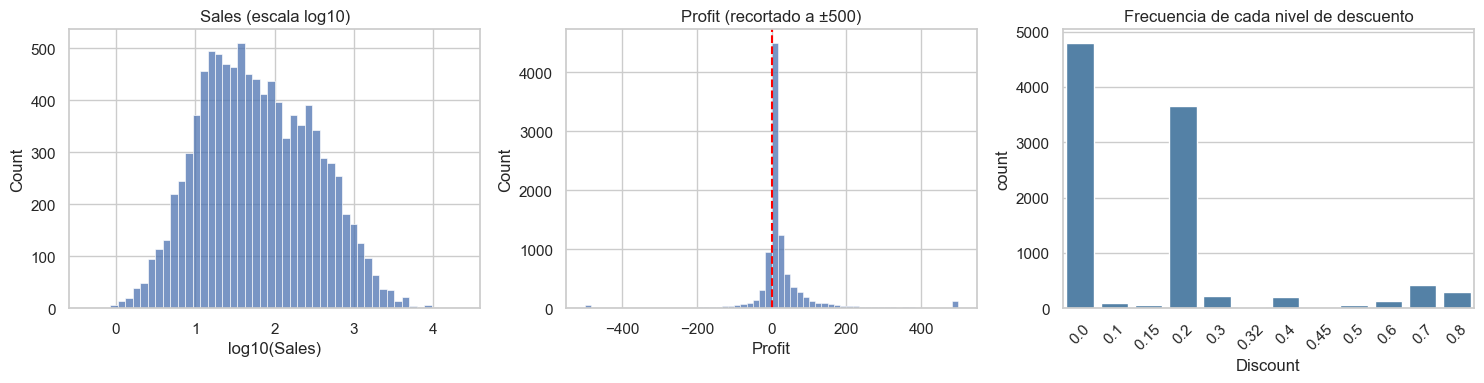

% de líneas de pedido con pérdida: 18.7%


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(np.log10(df['Sales']), bins=50, ax=axes[0])
axes[0].set_title('Sales (escala log10)'); axes[0].set_xlabel('log10(Sales)')
sns.histplot(df['Profit'].clip(-500, 500), bins=60, ax=axes[1])
axes[1].axvline(0, color='red', ls='--'); axes[1].set_title('Profit (recortado a ±500)')
sns.countplot(x='Discount', data=df, ax=axes[2], color='steelblue')
axes[2].set_title('Frecuencia de cada nivel de descuento'); axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

print(f"% de líneas de pedido con pérdida: {df['perdida'].mean():.1%}")

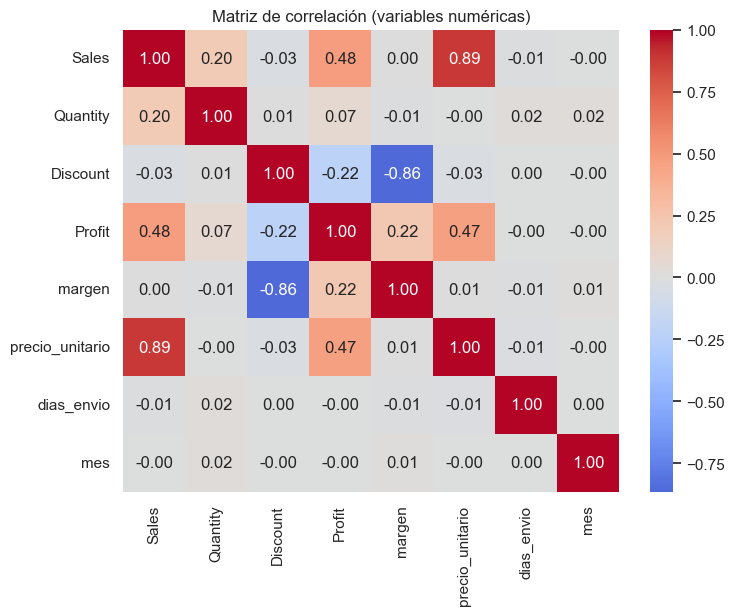

In [10]:
num_eda = ['Sales', 'Quantity', 'Discount', 'Profit', 'margen', 'precio_unitario', 'dias_envio', 'mes']
corr = df[num_eda].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación (variables numéricas)')
plt.show()

**Correlaciones:** `Discount` es la variable numérica más relacionada con el `margen` (correlación negativa fuerte). `Sales` y `precio_unitario` están muy correlacionadas, y es lógico, porque una se calcula a partir de la otra. Con `Profit` en valor absoluto las correlaciones son débiles por sus valores extremos. Eso apunta a relaciones **no lineales**, que es una razón para probar modelos de árboles.

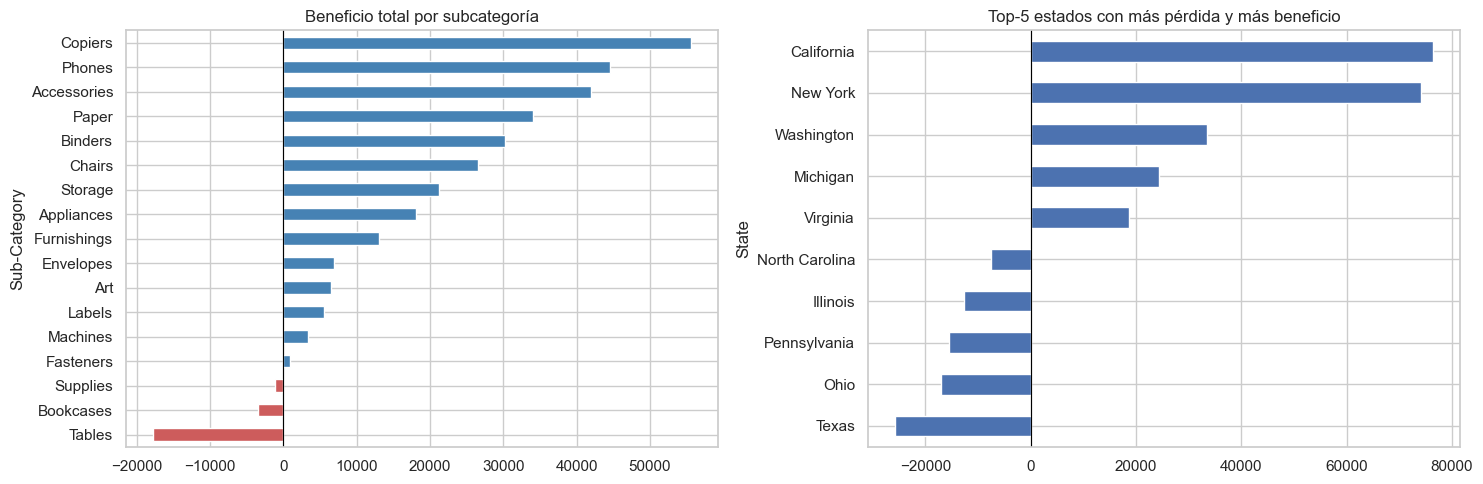

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
profit_sub = df.groupby('Sub-Category')['Profit'].sum().sort_values()
profit_sub.plot(kind='barh', ax=axes[0], color=np.where(profit_sub < 0, 'indianred', 'steelblue'))
axes[0].axvline(0, color='black', lw=0.8); axes[0].set_title('Beneficio total por subcategoría')

top_estados = df.groupby('State')['Profit'].sum().sort_values()
pd.concat([top_estados.head(5), top_estados.tail(5)]).plot(kind='barh', ax=axes[1])
axes[1].axvline(0, color='black', lw=0.8); axes[1].set_title('Top-5 estados con más pérdida y más beneficio')
plt.tight_layout(); plt.show()

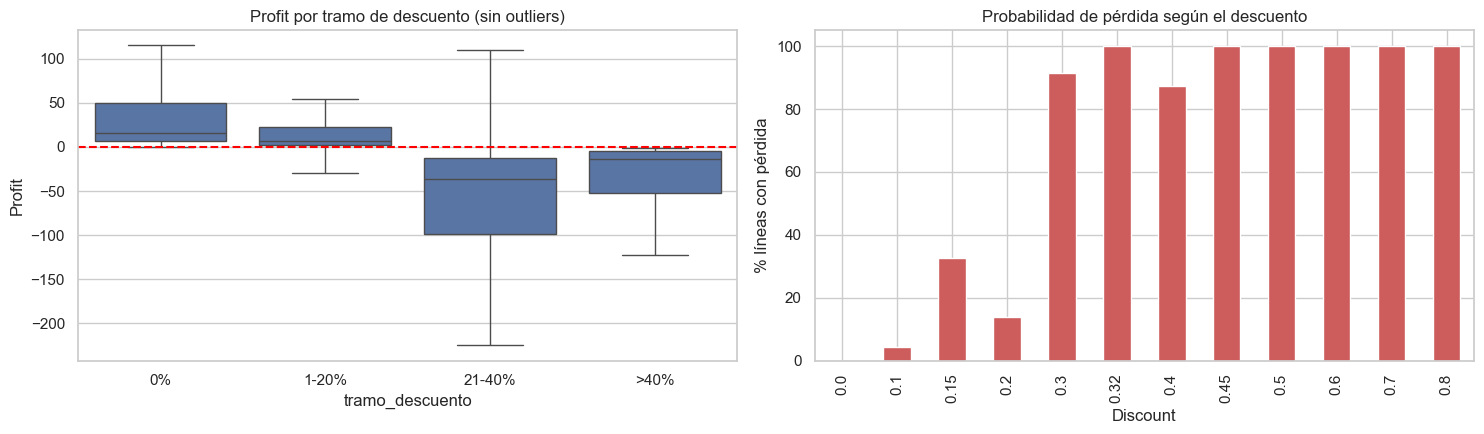

,lineas,profit_total,pct_perdida
tramo_descuento,,,
0%,4798,320987.60,0.00
1-20%,3803,100785.47,0.14
21-40%,459,-35805.41,0.90
>40%,933,-99558.59,1.00


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
sns.boxplot(x='tramo_descuento', y='Profit', data=df, ax=axes[0], showfliers=False)
axes[0].axhline(0, color='red', ls='--'); axes[0].set_title('Profit por tramo de descuento (sin outliers)')
(df.groupby('Discount')['perdida'].mean() * 100).plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_ylabel('% líneas con pérdida'); axes[1].set_title('Probabilidad de pérdida según el descuento')
plt.tight_layout(); plt.show()

df.groupby('tramo_descuento', observed=True).agg(lineas=('Profit', 'size'),
                                                 profit_total=('Profit', 'sum'),
                                                 pct_perdida=('perdida', 'mean')).round(2)

In [13]:
df.groupby('Region').agg(ventas=('Sales', 'sum'), beneficio=('Profit', 'sum'),
                         descuento_medio=('Discount', 'mean')).assign(
    margen=lambda t: t.beneficio / t.ventas).round(3).sort_values('margen')

,ventas,beneficio,descuento_medio,margen
Region,,,,
Central,501239.891,39706.362,0.240,0.079
South,391721.905,46749.430,0.147,0.119
East,678499.868,91534.839,0.145,0.135
West,725457.824,108418.449,0.109,0.149


### 1.1.7 Explicaciones y decisiones desde el punto de vista de negocio

1. **El 18,7 % de las líneas de pedido generan pérdida.** No es un caso aislado.
2. **El descuento es lo que más pesa.** Sin descuento, ninguna línea pierde dinero. Con un 20 % pierde el 14 %. **A partir del 30 % pierde casi el 100 %.** Las líneas con descuento de 30 % o más son el 14 % de las ventas y suman unos **−135.000 $** de beneficio, casi la mitad de lo que gana la empresa en total (≈286.000 $).
3. **Tres subcategorías dan pérdida en total:** *Tables*, *Bookcases* y *Supplies*. Las más rentables son *Copiers*, *Phones* y *Accessories*.
4. **Por geografía:** Texas, Ohio, Pennsylvania e Illinois concentran las pérdidas. La región **Central** tiene el peor margen (7,9 %) y también el descuento medio más alto (24 %). Las dos cosas van de la mano.

**Decisiones para el modelado:** usamos `Discount`, `Sub-Category`, `Region` y `Sales` como predictores clave. Elegimos métricas robustas a outliers (MAE) para la regresión. Y en clasificación tratamos el desbalanceo (81/19).

## Fase 1.2: Clasificación

1. Selección del target categórico
2. Entrenamiento de un primer modelo + cálculo de métricas
3. Gráficas clave (matriz de confusión y curva ROC comparativa)
4. Entrenamiento de un segundo modelo + cálculo de métricas
5. Gráficas clave segundo modelo (matriz de confusión y curva ROC comparativa)
6. Comparativa de métricas
7. Explicación: cuál eliges y por qué

### 1.2.1 Selección del target

**Target: `perdida` = 1 si la línea de pedido tiene `Profit < 0`.** Responde directamente a la pregunta de negocio ("¿qué genera pérdidas?") y coincide con la Vía 1 de la Fase 2.

> La versión anterior usaba `margen > mediana`. Ese target parte los datos en dos mitades iguales por construcción, y marca como "mala" una venta con un 10 % de margen, que en realidad es rentable. Además, no se corresponde con la pregunta de negocio.

Las clases están **desbalanceadas** (81 % sin pérdida, 19 % con pérdida), así que el split es estratificado y la accuracy no puede ser la métrica principal.

In [14]:
# Target y predictores (NO se incluye Profit ni margen: serían fuga de información)
X_clf = df[NUM_COLS + CAT_COLS]
y_clf = df['perdida']
print(y_clf.value_counts(normalize=True).round(3))

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf)

def metricas_clf(nombre, y_true, y_pred, y_prob):
    return {'modelo': nombre,
            'accuracy': accuracy_score(y_true, y_pred),
            'precision': precision_score(y_true, y_pred),
            'recall': recall_score(y_true, y_pred),
            'f1': f1_score(y_true, y_pred),
            'roc_auc': roc_auc_score(y_true, y_prob)}

perdida
0    0.813
1    0.187
Name: proportion, dtype: float64


### 1.2.2 Modelo 1 — Regresión logística

In [15]:
# MODELO 1 — Regresión logística (class_weight='balanced' por el desbalanceo 81/19)
log_model = Pipeline([('prep', crear_preprocesador()),
                      ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))])
log_model.fit(X_train_c, y_train_c)
y_pred_log = log_model.predict(X_test_c)
y_prob_log = log_model.predict_proba(X_test_c)[:, 1]

res_log = metricas_clf('Regresión logística', y_test_c, y_pred_log, y_prob_log)
print(pd.Series(res_log).drop('modelo').astype(float).round(3))
print('\n', classification_report(y_test_c, y_pred_log, target_names=['Sin pérdida', 'Pérdida']))

accuracy     0.920
precision    0.714
recall       0.955
f1           0.817
roc_auc      0.985
dtype: float64

               precision    recall  f1-score   support

 Sin pérdida       0.99      0.91      0.95      1625
     Pérdida       0.71      0.95      0.82       374

    accuracy                           0.92      1999
   macro avg       0.85      0.93      0.88      1999
weighted avg       0.94      0.92      0.92      1999



### 1.2.3 Gráficas clave — Regresión logística

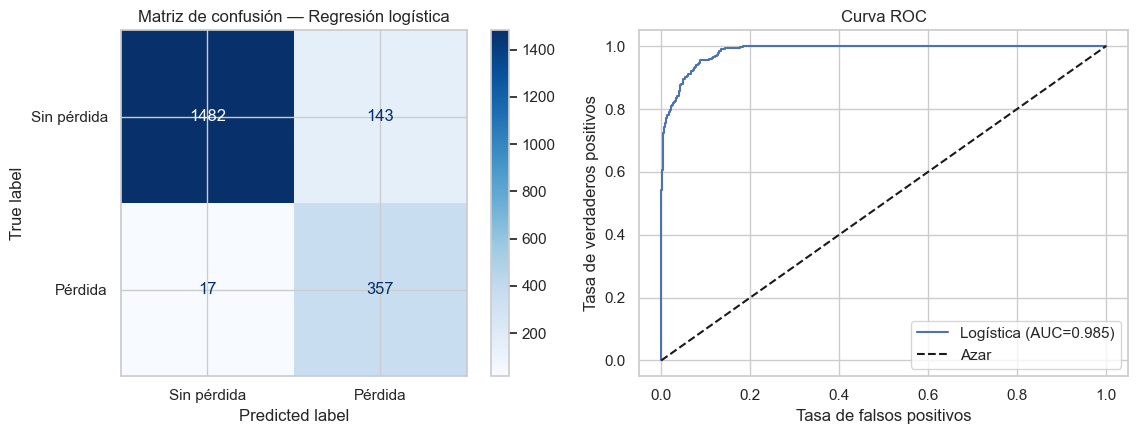

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test_c, y_pred_log, display_labels=['Sin pérdida', 'Pérdida'],
                                        cmap='Blues', ax=axes[0])
axes[0].set_title('Matriz de confusión — Regresión logística')
fpr, tpr, _ = roc_curve(y_test_c, y_prob_log)
axes[1].plot(fpr, tpr, label=f"Logística (AUC={res_log['roc_auc']:.3f})")
axes[1].plot([0, 1], [0, 1], 'k--', label='Azar')
axes[1].set_xlabel('Tasa de falsos positivos'); axes[1].set_ylabel('Tasa de verdaderos positivos')
axes[1].set_title('Curva ROC'); axes[1].legend()
plt.tight_layout(); plt.show()

### 1.2.4 Modelo 2 — KNN

In [17]:
# MODELO 2 — KNN. Elegimos k con validación cruzada (solo sobre train)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
resultados_k = {}
for k in [5, 15, 25, 35, 51, 75]:
    pipe = Pipeline([('prep', crear_preprocesador()), ('clf', KNeighborsClassifier(n_neighbors=k))])
    resultados_k[k] = cross_val_score(pipe, X_train_c, y_train_c, cv=cv, scoring='roc_auc').mean()
mejor_k = max(resultados_k, key=resultados_k.get)
print('ROC-AUC medio en CV por k:', {k: round(v, 3) for k, v in resultados_k.items()})
print('k elegido:', mejor_k)

ROC-AUC medio en CV por k: {5: np.float64(0.949), 15: np.float64(0.967), 25: np.float64(0.971), 35: np.float64(0.972), 51: np.float64(0.973), 75: np.float64(0.972)}
k elegido: 51


In [18]:
knn = Pipeline([('prep', crear_preprocesador()), ('clf', KNeighborsClassifier(n_neighbors=mejor_k))])
knn.fit(X_train_c, y_train_c)
y_prob_knn = knn.predict_proba(X_test_c)[:, 1]
y_pred_knn = (y_prob_knn >= 0.5).astype(int)

res_knn = metricas_clf(f'KNN (k={mejor_k})', y_test_c, y_pred_knn, y_prob_knn)
print(pd.Series(res_knn).drop('modelo').astype(float).round(3))
print('\n', classification_report(y_test_c, y_pred_knn, target_names=['Sin pérdida', 'Pérdida']))

accuracy     0.934
precision    0.962
recall       0.674
f1           0.792
roc_auc      0.977
dtype: float64

               precision    recall  f1-score   support

 Sin pérdida       0.93      0.99      0.96      1625
     Pérdida       0.96      0.67      0.79       374

    accuracy                           0.93      1999
   macro avg       0.95      0.83      0.88      1999
weighted avg       0.94      0.93      0.93      1999



### 1.2.5 Gráficas clave — KNN y ROC comparativa

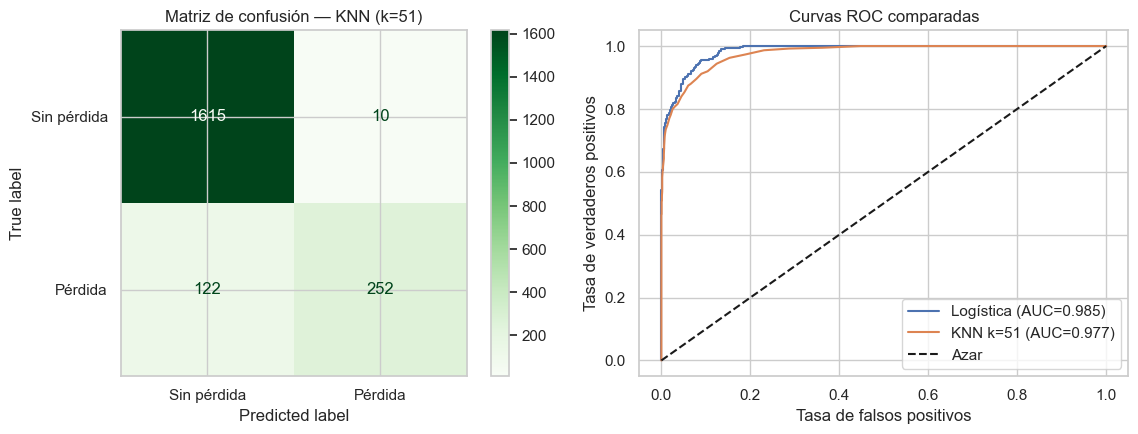

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test_c, y_pred_knn, display_labels=['Sin pérdida', 'Pérdida'],
                                        cmap='Greens', ax=axes[0])
axes[0].set_title(f'Matriz de confusión — KNN (k={mejor_k})')
for nombre, prob in [('Logística', y_prob_log), (f'KNN k={mejor_k}', y_prob_knn)]:
    fpr, tpr, _ = roc_curve(y_test_c, prob)
    axes[1].plot(fpr, tpr, label=f'{nombre} (AUC={roc_auc_score(y_test_c, prob):.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Azar')
axes[1].set_xlabel('Tasa de falsos positivos'); axes[1].set_ylabel('Tasa de verdaderos positivos')
axes[1].set_title('Curvas ROC comparadas'); axes[1].legend()
plt.tight_layout(); plt.show()

### 1.2.6 Comparativa de métricas

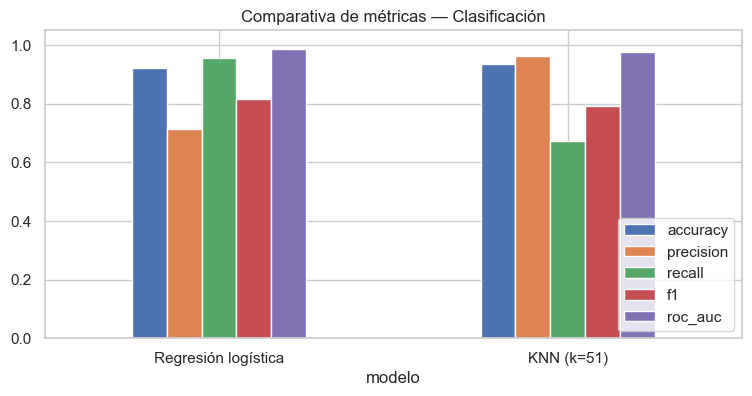

,accuracy,precision,recall,f1,roc_auc
modelo,,,,,
Regresión logística,0.920,0.714,0.955,0.817,0.985
KNN (k=51),0.934,0.962,0.674,0.792,0.977


In [20]:
tabla_clf = pd.DataFrame([res_log, res_knn]).set_index('modelo').round(3)
tabla_clf.plot(kind='bar', figsize=(9, 4), rot=0, title='Comparativa de métricas — Clasificación')
plt.ylim(0, 1.05); plt.legend(loc='lower right'); plt.show()
tabla_clf

### 1.2.7 ¿Qué modelo elegimos y por qué?

| | Regresión logística | KNN (k=51) |
|---|---|---|
| ROC-AUC | **0,985** | 0,977 |
| Recall de pérdida | **0,95** | 0,67 |
| Precisión de pérdida | 0,71 | **0,96** |
| Accuracy | 0,92 | 0,93 |

**Elegimos la regresión logística.**
- El objetivo de negocio es **detectar las ventas que van a generar pérdida antes de cerrarlas**. Dejar pasar una pérdida (falso negativo) cuesta más que revisar una venta que al final era rentable (falso positivo). La logística detecta el **95 % de las pérdidas**; KNN solo el 67 %.
- También tiene mejor ROC-AUC, es más ligera y sus coeficientes se pueden explicar a negocio.
- KNN tiene algo más de accuracy, pero en un dataset desbalanceado esa métrica engaña: un modelo que dijera siempre "sin pérdida" ya acertaría el 81 %.

**Cómo leer las métricas** (en la versión anterior estaban mal interpretadas):
- **ROC-AUC = 0,985** no significa "98,5 % de aciertos". Es la probabilidad de que el modelo le asigne más riesgo a una venta con pérdida que a una sin pérdida, si se eligen ambas al azar.
- Un AUC tan alto tiene explicación: **el descuento casi determina por sí solo si hay pérdida** (30 % o más → pérdida casi segura). No es fuga de información, porque el descuento se conoce antes de vender. Pero indica que el modelo está aprendiendo una regla de negocio muy clara, y esa regla es en sí misma una conclusión útil.

## Fase 1.3: Regresión

1. Selección del target numérico
2. Entrenamiento de un primer modelo + cálculo de métricas
3. Gráficas clave (visualización de predicciones)
4. Entrenamiento de un segundo modelo + cálculo de métricas
5. Gráficas clave segundo modelo (visualización de predicciones)
6. Comparativa de métricas
7. Explicación: cuál eliges y por qué

### 1.3.1 Selección del target

**Target: `Profit`** de cada línea de pedido. Los predictores son los mismos que en clasificación: datos que se conocen en el momento de la venta. **Nunca** usamos `margen` ni `perdida`, porque ambos se calculan a partir del Profit.

Como `Profit` tiene colas muy largas, damos tres métricas: **MAE** (error medio en $, robusto a outliers), **RMSE** (castiga más los errores grandes) y **R²**.

In [21]:
# Target numérico: Profit. Mismos predictores (sin Profit/margen)
X_reg = df[NUM_COLS + CAT_COLS]
y_reg = df['Profit']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE)

def metricas_reg(nombre, y_true, y_pred):
    return {'modelo': nombre,
            'MAE': mean_absolute_error(y_true, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
            'R2': r2_score(y_true, y_pred)}

def grafico_pred(y_true, y_pred, titulo, ax):
    ax.scatter(y_true, y_pred, alpha=0.3, s=12)
    lim = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lim, lim, 'r--', label='Predicción perfecta')
    ax.set_xlabel('Profit real'); ax.set_ylabel('Profit predicho'); ax.set_title(titulo); ax.legend()

### 1.3.2 Modelo 1 — Regresión lineal (+ gráficas)

MAE      70.854
RMSE    326.284
R2       -0.309
dtype: float64


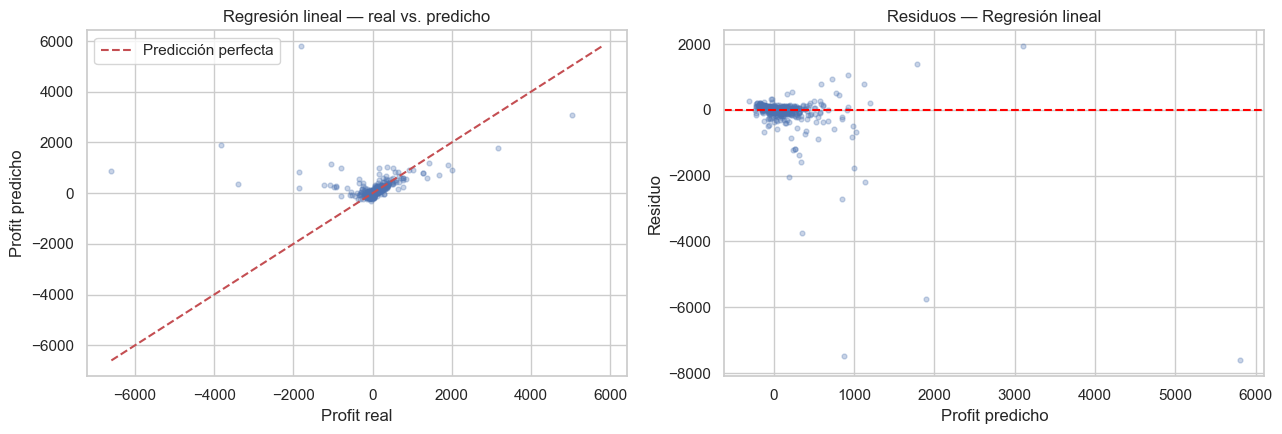

In [22]:
# MODELO 1 — Regresión lineal
lin_model = Pipeline([('prep', crear_preprocesador()), ('reg', LinearRegression())])
lin_model.fit(X_train_r, y_train_r)
y_pred_lin = lin_model.predict(X_test_r)
res_lin = metricas_reg('Regresión lineal', y_test_r, y_pred_lin)
print(pd.Series(res_lin).drop('modelo').astype(float).round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
grafico_pred(y_test_r, y_pred_lin, 'Regresión lineal — real vs. predicho', axes[0])
axes[1].scatter(y_pred_lin, y_test_r - y_pred_lin, alpha=0.3, s=12)
axes[1].axhline(0, color='red', ls='--'); axes[1].set_xlabel('Profit predicho'); axes[1].set_ylabel('Residuo')
axes[1].set_title('Residuos — Regresión lineal')
plt.tight_layout(); plt.show()

### 1.3.3 Modelo 2 — Random Forest (+ gráficas)

MAE      29.789
RMSE    264.696
R2        0.138
dtype: float64


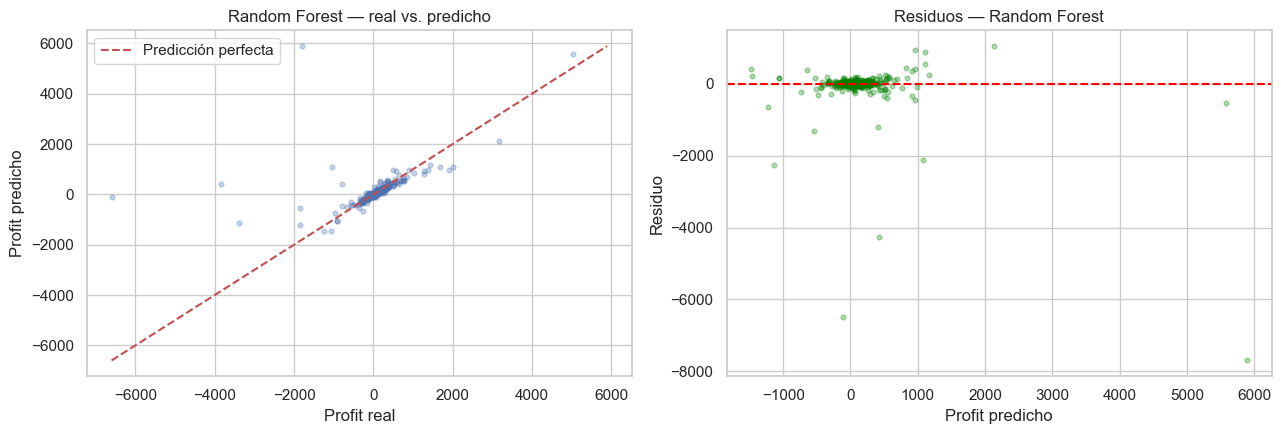

In [23]:
# MODELO 2 — Random Forest (no necesita escalado, pero reutilizamos el pipeline por coherencia)
rf_reg = Pipeline([('prep', crear_preprocesador()),
                   ('reg', RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                                                 n_jobs=-1, random_state=RANDOM_STATE))])
rf_reg.fit(X_train_r, y_train_r)
y_pred_rf1 = rf_reg.predict(X_test_r)
res_rf1 = metricas_reg('Random Forest', y_test_r, y_pred_rf1)
print(pd.Series(res_rf1).drop('modelo').astype(float).round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
grafico_pred(y_test_r, y_pred_rf1, 'Random Forest — real vs. predicho', axes[0])
axes[1].scatter(y_pred_rf1, y_test_r - y_pred_rf1, alpha=0.3, s=12, color='green')
axes[1].axhline(0, color='red', ls='--'); axes[1].set_xlabel('Profit predicho'); axes[1].set_ylabel('Residuo')
axes[1].set_title('Residuos — Random Forest')
plt.tight_layout(); plt.show()

### 1.3.4 Comparativa de métricas

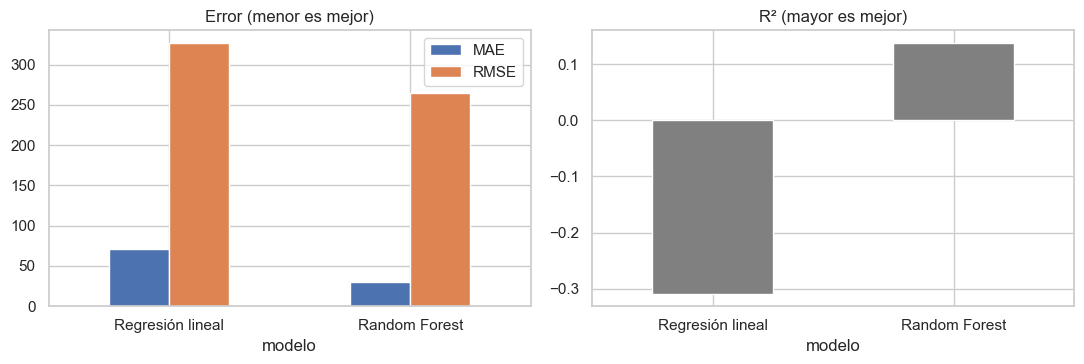

,MAE,RMSE,R2,R2_CV_medio
modelo,,,,
Regresión lineal,70.854,326.284,-0.309,0.300
Random Forest,29.789,264.696,0.138,0.712


In [24]:
tabla_reg = pd.DataFrame([res_lin, res_rf1]).set_index('modelo')
# Un único split es inestable con un target de colas tan largas: añadimos R² medio con validación cruzada (5 folds)
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
tabla_reg['R2_CV_medio'] = [cross_val_score(m, X_reg, y_reg, cv=kf, scoring='r2').mean()
                            for m in [lin_model, rf_reg]]
tabla_reg = tabla_reg.round(3)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
tabla_reg[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0], rot=0, title='Error (menor es mejor)')
tabla_reg['R2'].plot(kind='bar', ax=axes[1], rot=0, color='gray', title='R² (mayor es mejor)')
plt.tight_layout(); plt.show()
tabla_reg

### 1.3.5 ¿Qué modelo elegimos y por qué?

**Elegimos Random Forest.**
- **MAE:** de media, el Random Forest se equivoca en ≈30 $ por línea de pedido; la regresión lineal, en ≈71 $. *(El MAE no es "el número de veces que se equivoca el modelo", como decía la versión anterior. Es el error medio expresado en dólares.)*
- **R²:** en este split de test el R² es bajo para los dos modelos (lineal −0,31; RF 0,14). Pero con **validación cruzada de 5 folds** sube a **0,30 en la lineal y 0,71 en el RF**. La diferencia se debe a que el conjunto de test contiene unos pocos pedidos extremos (pérdidas de miles de dólares) que hunden el R² de un único split. Por eso **no conviene sacar conclusiones con un solo split** cuando el target tiene colas tan largas.
- La regresión lineal no puede representar que el efecto del descuento dependa del producto (interacción *Discount × Sub-Category*) ni el salto brusco al 30 %. Los árboles sí. Esto justifica pasar a modelos de árboles en la Fase 2.

## Fase 1.4: PCA y No Supervisados

1. Aplicación de PCA
2. Visualización de la reducción de dimensiones
3. Interpretación de los componentes principales
4. Selección de un modelo no supervisado (KMeans, DBSCAN o LOF)
5. Entrenamiento del modelo seleccionado
6. Visualización de resultados (clusters o anomalías)
7. Cálculo de métricas si aplica
8. Interpretación de resultados desde un punto de vista de negocio

Explicación: qué patrones se han descubierto y qué implicaciones tendría para negocio

### 1.4.0 De líneas de pedido a clientes

La pregunta de negocio habla de **segmentar clientes**, así que agrupamos las 9.993 líneas en **793 clientes**, con variables de comportamiento: frecuencia, ventas, beneficio, margen, descuento medio, % de líneas con pérdida, recencia y ticket medio.

> En la versión anterior, el PCA se hacía sobre líneas de pedido e incluía columnas duplicadas (`Shipping Time` y `dias_envio`) y el propio target (`alta_rentabilidad`). Uno de los 4 clusters era solo un puñado de outliers, y los nombres de los segmentos no salían de ningún análisis de perfil.

In [25]:
# Agregamos las líneas de pedido a nivel CLIENTE (la pregunta de negocio habla de clientes)
fecha_ref = df['Order Date'].max()
clientes = df.groupby('Customer ID').agg(
    n_pedidos=('Order ID', 'nunique'),
    ventas_total=('Sales', 'sum'),
    beneficio_total=('Profit', 'sum'),
    descuento_medio=('Discount', 'mean'),
    pct_lineas_perdida=('perdida', 'mean'),
    dias_desde_ultima=('Order Date', lambda s: (fecha_ref - s.max()).days),
)
clientes['margen'] = clientes['beneficio_total'] / clientes['ventas_total']
clientes['ticket_medio'] = clientes['ventas_total'] / clientes['n_pedidos']
print('Clientes:', clientes.shape[0])
clientes.describe().round(2)

Clientes: 793


,n_pedidos,ventas_total,beneficio_total,descuento_medio,pct_lineas_perdida,dias_desde_ultima,margen,ticket_medio
count,793.00,793.00,793.00,793.00,793.00,793.00,793.00,793.00
mean,6.32,2896.49,361.17,0.16,0.19,146.80,0.11,460.10
std,2.55,2628.41,894.25,0.09,0.16,186.21,0.19,433.39
min,1.00,4.83,-6626.39,0.00,0.00,0.00,-1.16,2.42
25%,5.00,1146.05,36.61,0.09,0.07,30.00,0.04,213.26
50%,6.00,2256.39,227.83,0.15,0.17,75.00,0.14,362.50
75%,8.00,3785.28,560.01,0.21,0.29,183.00,0.22,550.38
max,17.00,25043.05,8981.32,0.70,1.00,1165.00,0.48,5008.61


### 1.4.1 Aplicación de PCA

In [26]:
VARS_CLUSTER = ['n_pedidos', 'ventas_total', 'beneficio_total', 'margen',
                'descuento_medio', 'pct_lineas_perdida', 'dias_desde_ultima', 'ticket_medio']

X_cli = clientes[VARS_CLUSTER].copy()
# Ventas y ticket muy asimétricos -> log; beneficio tiene negativos -> transformación simétrica
for c in ['ventas_total', 'ticket_medio']:
    X_cli[c] = np.log1p(X_cli[c])
X_cli['beneficio_total'] = np.sign(X_cli['beneficio_total']) * np.log1p(X_cli['beneficio_total'].abs())

scaler_cli = StandardScaler()
X_cli_scaled = scaler_cli.fit_transform(X_cli)

pca_full = PCA().fit(X_cli_scaled)
var_exp = pca_full.explained_variance_ratio_
print('Varianza explicada por componente:', np.round(var_exp, 3))
print('Acumulada:', np.round(np.cumsum(var_exp), 3))

Varianza explicada por componente: [0.378 0.27  0.146 0.09  0.074 0.024 0.018 0.001]
Acumulada: [0.378 0.648 0.793 0.883 0.957 0.981 0.999 1.   ]


### 1.4.2 Visualización de la reducción de dimensiones

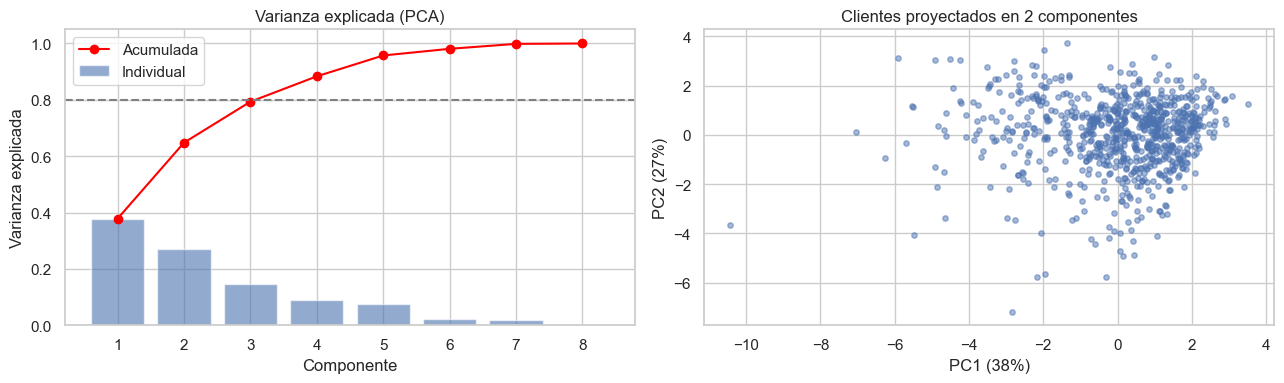

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(1, len(var_exp) + 1), var_exp, alpha=0.6, label='Individual')
axes[0].plot(range(1, len(var_exp) + 1), np.cumsum(var_exp), 'o-', color='red', label='Acumulada')
axes[0].axhline(0.8, ls='--', color='gray'); axes[0].set_xlabel('Componente')
axes[0].set_ylabel('Varianza explicada'); axes[0].set_title('Varianza explicada (PCA)'); axes[0].legend()

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cli_scaled)
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, s=15)
axes[1].set_xlabel(f'PC1 ({var_exp[0]:.0%})'); axes[1].set_ylabel(f'PC2 ({var_exp[1]:.0%})')
axes[1].set_title('Clientes proyectados en 2 componentes')
plt.tight_layout(); plt.show()

### 1.4.3 Interpretación de los componentes principales

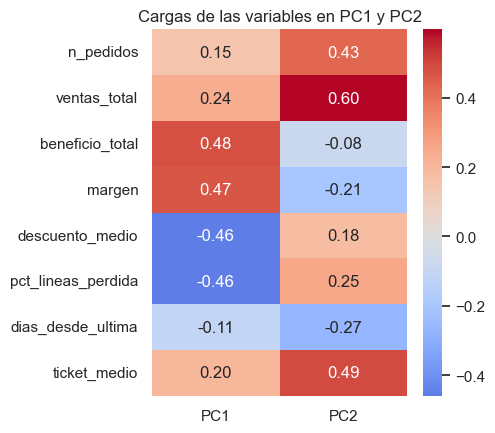

In [28]:
cargas = pd.DataFrame(pca.components_.T, index=VARS_CLUSTER, columns=['PC1', 'PC2'])
plt.figure(figsize=(5, 4.5))
sns.heatmap(cargas, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Cargas de las variables en PC1 y PC2'); plt.tight_layout(); plt.show()

- Con **2 componentes explicamos ≈65 % de la varianza** y con 3, ≈79 %. Basta para visualizar los datos, aunque se pierde información. Por eso el clustering se hace sobre las 8 variables estandarizadas, y el PCA se usa solo para dibujar los resultados.
- **PC1 = eje de rentabilidad.** Pesan en positivo el beneficio y el margen, y en negativo el descuento medio y el % de líneas con pérdida. Valores altos indican un cliente sano.
- **PC2 = eje de volumen.** Pesan las ventas totales, el ticket medio y el nº de pedidos. Valores altos indican un cliente grande y activo.

### 1.4.4 Selección del modelo no supervisado

Elegimos **KMeans**: buscamos segmentos de clientes para hacer campañas, no anomalías. Para elegir k usamos el método del codo y el coeficiente de silueta.

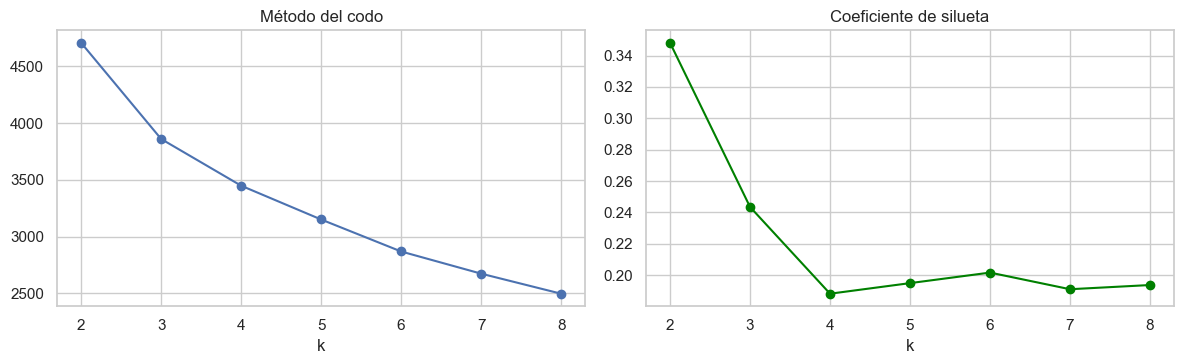

{2: np.float64(0.348), 3: np.float64(0.243), 4: np.float64(0.188), 5: np.float64(0.195), 6: np.float64(0.202), 7: np.float64(0.191), 8: np.float64(0.194)}


In [29]:
inercias, siluetas = [], []
rango_k = range(2, 9)
for k in rango_k:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_cli_scaled)
    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_cli_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(list(rango_k), inercias, 'o-'); axes[0].set_title('Método del codo'); axes[0].set_xlabel('k')
axes[1].plot(list(rango_k), siluetas, 'o-', color='green'); axes[1].set_title('Coeficiente de silueta')
axes[1].set_xlabel('k')
plt.tight_layout(); plt.show()
print(dict(zip(rango_k, np.round(siluetas, 3))))

La silueta más alta se da con k=2 (0,35), pero dos grupos ("buenos" y "malos") no sirven para diseñar campañas. **Elegimos k=4** porque la inercia ya baja poco a partir de ahí y la silueta se mantiene estable entre k=4 y k=8. Además, los 4 segmentos que salen se pueden interpretar y accionar desde negocio. La silueta de ≈0,19 indica que los grupos se solapan algo, como es habitual con datos de comportamiento de clientes.

### 1.4.5 Entrenamiento y visualización

Silueta con k=4: 0.188


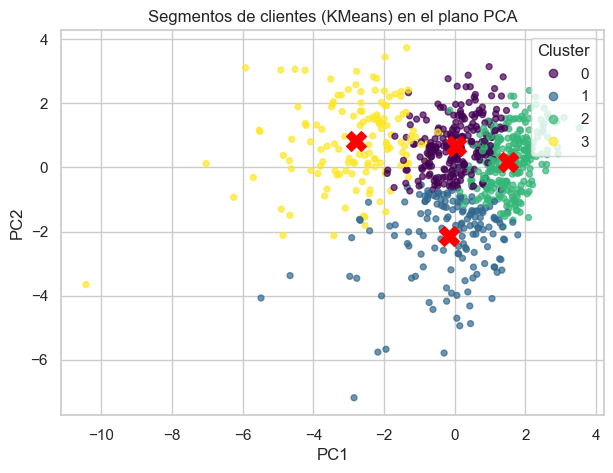

In [30]:
K = 4
kmeans = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE)
clientes['cluster'] = kmeans.fit_predict(X_cli_scaled)
print(f'Silueta con k={K}: {silhouette_score(X_cli_scaled, clientes["cluster"]):.3f}')

plt.figure(figsize=(7, 5))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clientes['cluster'], cmap='viridis', alpha=0.7, s=18)
centros_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centros_pca[:, 0], centros_pca[:, 1], c='red', marker='X', s=200, label='Centroides')
plt.legend(*sc.legend_elements(), title='Cluster', loc='upper right')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('Segmentos de clientes (KMeans) en el plano PCA')
plt.show()

### 1.4.6 Perfil de los clusters

In [31]:
perfil = clientes.groupby('cluster')[VARS_CLUSTER].mean()
perfil.insert(0, 'n_clientes', clientes['cluster'].value_counts().sort_index())
perfil['% beneficio total'] = clientes.groupby('cluster')['beneficio_total'].sum() / clientes['beneficio_total'].sum()

# Nombre de cada segmento a partir de su perfil (no a mano: así no depende del número que asigne KMeans)
nombres = {perfil['beneficio_total'].idxmax(): 'Rentables',
           perfil['beneficio_total'].idxmin(): 'Destructores de margen'}
resto = perfil.drop(index=list(nombres))['n_pedidos'].sort_values()
nombres[resto.index[0]]  = 'Ocasionales / poco activos'
nombres[resto.index[-1]] = 'Frecuentes con descuento'
perfil.insert(0, 'segmento', perfil.index.map(nombres))
clientes['segmento'] = clientes['cluster'].map(nombres)
perfil.round(2)

,segmento,n_clientes,n_pedidos,ventas_total,beneficio_total,margen,descuento_medio,pct_lineas_perdida,dias_desde_ultima,ticket_medio,% beneficio total
cluster,,,,,,,,,,,
0,Frecuentes con descuento,236,7.83,3192.96,400.39,0.12,0.20,0.25,105.49,414.43,0.33
1,Ocasionales / poco activos,150,4.20,605.55,109.02,0.19,0.13,0.11,220.15,152.70,0.06
2,Rentables,268,6.49,4050.85,916.81,0.21,0.09,0.07,122.97,657.83,0.86
3,Destructores de margen,139,5.68,2639.72,-504.62,-0.20,0.25,0.38,183.73,488.15,-0.24


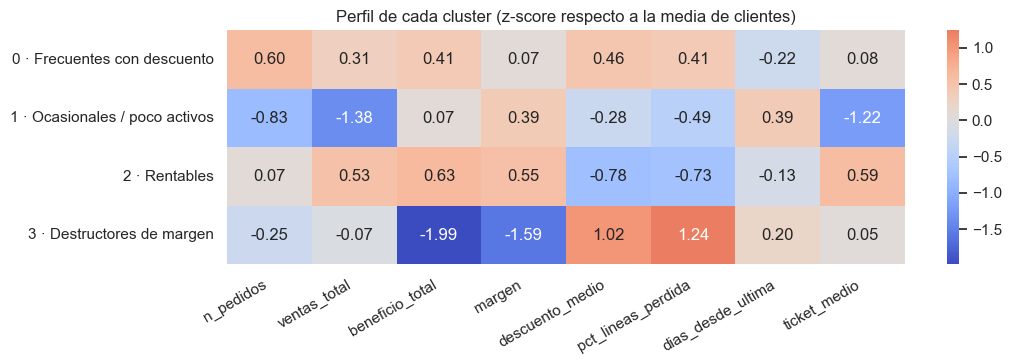

In [32]:
# Perfil estandarizado (z-score de cada variable) para leer los clusters de un vistazo
perfil_z = pd.DataFrame(X_cli_scaled, columns=VARS_CLUSTER, index=clientes.index).groupby(clientes['cluster']).mean()
perfil_z.index = [f'{c} · {nombres[c]}' for c in perfil_z.index]
plt.figure(figsize=(11, 3.8))
sns.heatmap(perfil_z, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Perfil de cada cluster (z-score respecto a la media de clientes)')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

### 1.4.7 Interpretación de negocio

| Segmento | Clientes | Perfil | Acción |
|---|---|---|---|
| 🟢 **Rentables** | ≈268 (34 %) | Mayor ticket y margen (≈21 %), poco descuento (9 %) | Fidelizar: programa premium y venta cruzada. **Generan ≈86 % del beneficio** |
| 🔵 **Frecuentes con descuento** | ≈236 (30 %) | Los que más pedidos hacen, pero con un 20 % de descuento medio y 25 % de líneas con pérdida | Mantener la relación y bajar el descuento poco a poco. Margen de mejora alto |
| 🟡 **Ocasionales / poco activos** | ≈150 (19 %) | Pocos pedidos, ticket bajo, llevan >200 días sin comprar | Campañas de reactivación de bajo coste |
| 🔴 **Destructores de margen** | ≈139 (18 %) | Margen negativo (−20 %), 25 % de descuento medio, 38 % de líneas con pérdida | Revisar sus condiciones comerciales: limitar descuentos o subir precios. **Restan ≈24 % del beneficio total** |

*(El número de cada cluster puede cambiar entre versiones de scikit-learn, pero el nombre del segmento se asigna automáticamente según su perfil.)*

----

## 🔒 FASE 2

## Contexto y objetivo

Una vez llegados aquí, podríamos seguir el ejercicio por dos vias.


**Vía 1:**
Clasificación: Cliente rentable vs no rentable ( Profit > 0 )

**Vía 2:**
Regresión: Predicción del profit

**Vía 3:**
Calcular ambos tipos de modelos.


Para no hacer el ejercicio muy largo optaremos por la vía 2, predicción del profit, dejamos como opcional la vía 1.

*(La Vía 1 la hemos resuelto en la Fase 1.2 a nivel de línea de pedido.)*

# Fase 2 - Elección razonada del modelo

Antes de entrenar cualquier modelo, un buen científico de datos **justifica su elección**. Esta reflexión es clave en proyectos reales: los stakeholders querrán saber por qué usamos un algoritmo concreto.

### ¿Por qué modelos basados en árboles para predecir el Profit?

| Criterio | Situación en nuestro dataset | Ventaja de los árboles |
|----------|------------------------------|------------------------|
| **Relaciones no lineales** | Descuento alto → Profit negativo de forma no lineal | Los árboles capturan estas curvas sin transformaciones |
| **Interacciones entre variables** | Categoría + Descuento → Profit muy diferente | Los árboles modelan interacciones automáticamente |
| **Variables mixtas** | Numéricas (Sales) y categóricas codificadas | No requieren escalado ni normalización |
| **Outliers en el target** | Profit tiene valores extremos (pérdidas y ganancias grandes) | Más robustos que la regresión lineal |
| **Interpretabilidad** | El negocio quiere entender qué impulsa el beneficio | Feature importance + SHAP |

**Nuestra hipótesis:** esperamos que funcionen mejor los **ensembles de árboles (Random Forest / XGBoost)**. El EDA mostró un efecto umbral del descuento (salto en el 30 %), interacciones descuento × subcategoría y un target con muchos outliers. Además, en la Fase 1.3 el Random Forest ya superaba con claridad a la regresión lineal. Para comprobarlo, comparamos tres modelos con el mismo split y las mismas métricas.

In [33]:
# Fase 2: Vía 2 — predicción del Profit con modelos de árboles.
# Los árboles no necesitan escalado: usamos la versión one-hot sin escalar (X_arboles) y el MISMO split que en 1.3
X_train, X_test = X_arboles.loc[X_train_r.index], X_arboles.loc[X_test_r.index]
y_train, y_test = y_train_r, y_test_r
print(X_train.shape, X_test.shape)
resultados_f2 = []

(7994, 32) (1999, 32)


---
## Fase 2.1 - Decision Tree: El Baseline

Empezamos con el modelo más sencillo. Un árbol de decisión individual nos servirá como **línea base** (baseline): cualquier modelo más complejo deberá superarlo.

💡 **Analogía de negocio:** El árbol de decisión es como el proceso de aprobación manual de un crédito: el gestor sigue un formulario de preguntas fijas. Funciona, pero es rígido y fácil de engañar.

In [34]:
dt_model = DecisionTreeRegressor(max_depth=5, min_samples_leaf=10, random_state=RANDOM_STATE)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)
resultados_f2.append(metricas_reg('Decision Tree (baseline)', y_test, dt_preds))
print(pd.Series(resultados_f2[-1]).drop('modelo').astype(float).round(3))

MAE      54.352
RMSE    319.073
R2       -0.252
dtype: float64


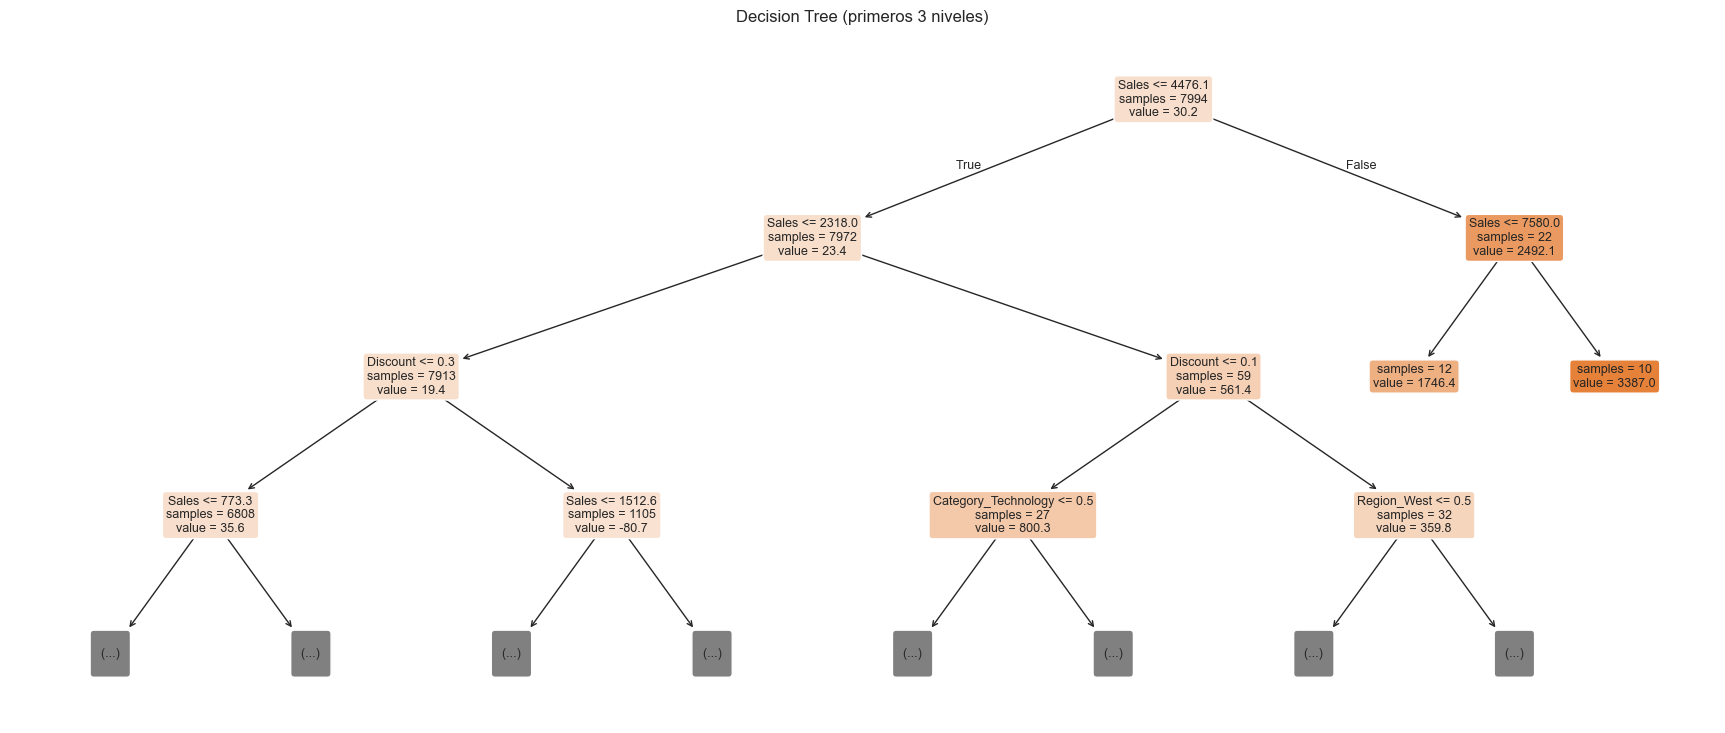

In [35]:
plt.figure(figsize=(22, 9))
plot_tree(dt_model, feature_names=X_train.columns, filled=True, rounded=True,
          max_depth=3, fontsize=9, impurity=False, precision=1)
plt.title('Decision Tree (primeros 3 niveles)')
plt.show()

**✍️ Conclusiones sobre este modelo**

- El árbol decide primero por **`Sales`**: unos pocos pedidos muy grandes concentran los beneficios y las pérdidas extremas. Dentro de los pedidos normales, el corte más importante es **`Discount ≤ 0,3`**. Por debajo, el beneficio medio es positivo; por encima, pasa a ser negativo (≈ −80 $ de media). Es el mismo umbral que vimos en el EDA.
- Las reglas son fáciles de leer y se pueden trasladar a una política comercial. Por ejemplo: *"no aprobar descuentos superiores al 30 % sin revisión"*.
- Como modelo predictivo es pobre (R² negativo en test). Un árbol solo, con `max_depth=5`, es demasiado rígido y sensible a los outliers. Por eso sirve como baseline que los ensembles deben superar.

---
## Fase 2.2 - Random Forest: Bagging

💡 **Analogía de negocio:** Es como pedir opinión a 200 asesores financieros independientes y hacer la media. Ninguno es perfecto, pero juntos son mucho más fiables que uno solo.

In [36]:
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, max_features='sqrt',
                                 n_jobs=-1, random_state=RANDOM_STATE)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
resultados_f2.append(metricas_reg('Random Forest', y_test, rf_preds))
print(pd.Series(resultados_f2[-1]).drop('modelo').astype(float).round(3))

MAE      43.373
RMSE    239.797
R2        0.293
dtype: float64


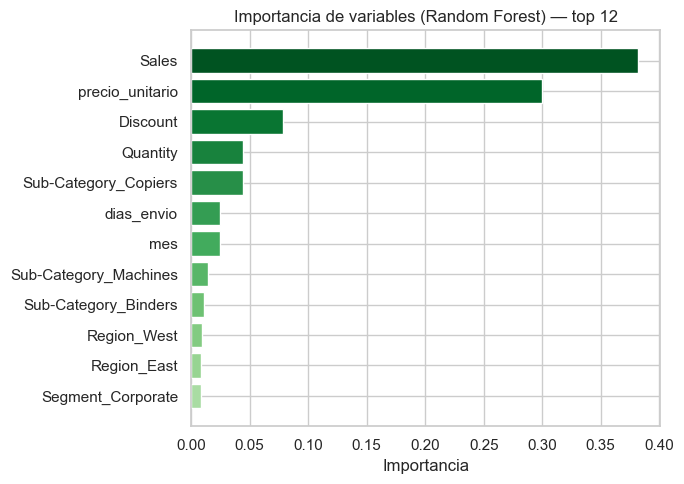

In [37]:
feat_imp = (pd.Series(rf_model.feature_importances_, index=X_train.columns)
              .sort_values().tail(12))
colores = plt.cm.Greens(np.linspace(0.35, 0.95, len(feat_imp)))
plt.figure(figsize=(7, 5))
plt.barh(feat_imp.index, feat_imp.values, color=colores)
plt.title('Importancia de variables (Random Forest) — top 12'); plt.xlabel('Importancia')
plt.tight_layout(); plt.show()

Configuramos el Random Forest con `max_depth=10` para evitar el sobreajuste, `max_features='sqrt'` para que los árboles sean distintos entre sí y generalicen mejor, `n_jobs=-1` para usar todos los núcleos y `random_state=42` para que los resultados sean reproducibles.

**Importancia de variables:** `Sales` y `precio_unitario` son las que más pesan, seguidas de `Discount`, `Quantity` y la subcategoría *Copiers*. Hay que tener en cuenta que esta importancia (por impureza) favorece a las variables continuas con muchos valores distintos; SHAP (Fase 2.5) da una medida más fiable. El RF reduce mucho el error del árbol individual.

---
## Fase 2.3 - XGBoost: Boosting

💡 **Analogía de negocio:** En lugar de promediar opiniones (Random Forest), el equipo hace una **revisión por rondas**: en cada ronda analiza los casos donde se equivocó antes y manda al mejor especialista para corregirlos.

In [38]:
xgb_model = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8,
                         colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1,
                         random_state=RANDOM_STATE, verbosity=0)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)
resultados_f2.append(metricas_reg('XGBoost', y_test, xgb_preds))
print(pd.Series(resultados_f2[-1]).drop('modelo').astype(float).round(3))

MAE      26.755
RMSE    205.440
R2        0.481
dtype: float64


Usamos XGBoost por su alto rendimiento con datos tabulares y porque captura relaciones no lineales complejas. Para controlar la complejidad y evitar el sobreajuste usamos `max_depth=6`, `learning_rate=0.05`, submuestreo de filas y columnas (`subsample`, `colsample_bytree` = 0,8) y regularización (`reg_alpha`, `reg_lambda`).

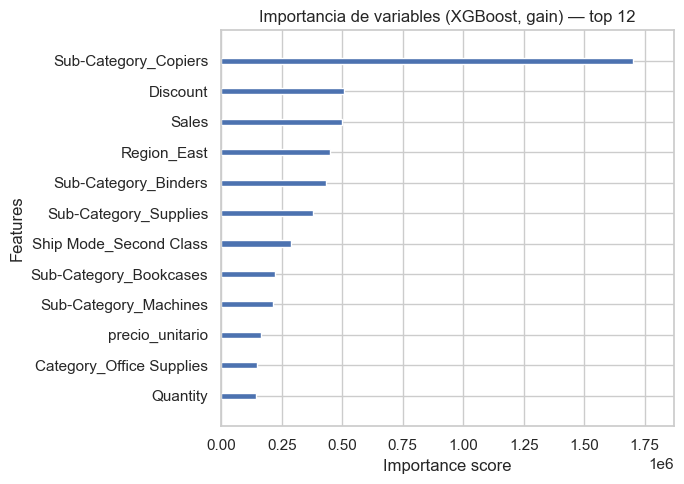

In [39]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_importance(xgb_model, ax=ax, max_num_features=12, importance_type='gain', show_values=False)
ax.set_title('Importancia de variables (XGBoost, gain) — top 12')
plt.tight_layout(); plt.show()

### Comparativa de los tres modelos (antes del ajuste)

In [40]:
tabla_f2 = pd.DataFrame(resultados_f2).set_index('modelo').round(3)
tabla_f2

,MAE,RMSE,R2
modelo,,,
Decision Tree (baseline),54.352,319.073,-0.252
Random Forest,43.373,239.797,0.293
XGBoost,26.755,205.440,0.481


---
## Fase 2.4 — Fine-tuning con GridSearchCV

💡 **Analogía de negocio:** Es como testear sistemáticamente distintas configuraciones de una campaña de marketing (audiencia × presupuesto × creatividad) y quedarte con la combinación que maximiza el ROI.

In [41]:
param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 1.0],
}
grid_search = GridSearchCV(
    estimator=XGBRegressor(random_state=RANDOM_STATE, verbosity=0),
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print('Mejores hiperparámetros:', grid_search.best_params_)
print(f'RMSE medio en validación cruzada: {-grid_search.best_score_:.2f}')

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Mejores hiperparámetros: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 400, 'subsample': 0.7}
RMSE medio en validación cruzada: 110.37


GridSearchCV prueba las 32 combinaciones de hiperparámetros con validación cruzada de 5 folds (160 entrenamientos) y se queda con la de menor RMSE medio. Como solo usa train, el test sigue sin tocarse para la evaluación final.

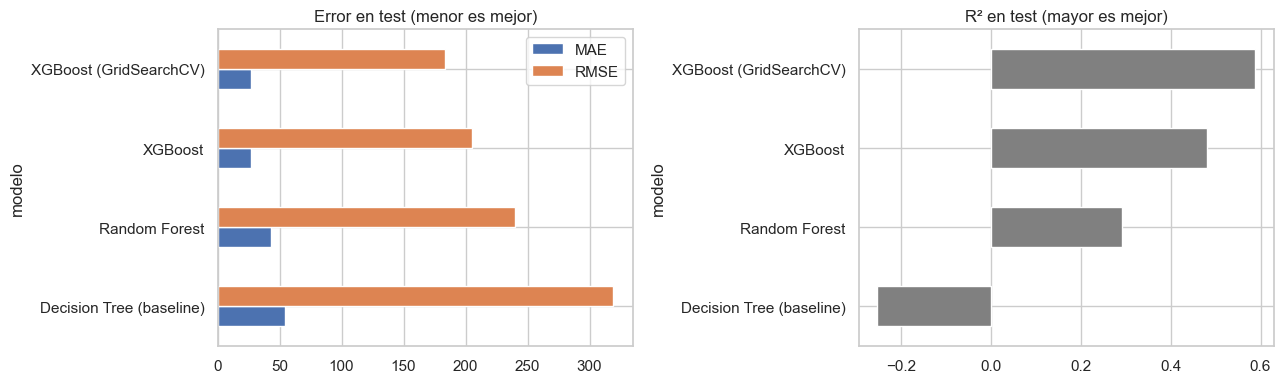

Modelo con menor RMSE en test: XGBoost (GridSearchCV)


,MAE,RMSE,R2
modelo,,,
Decision Tree (baseline),54.352,319.073,-0.252
Random Forest,43.373,239.797,0.293
XGBoost,26.755,205.440,0.481
XGBoost (GridSearchCV),27.010,183.127,0.588


In [42]:
xgb_best = grid_search.best_estimator_
xgb_best_preds = xgb_best.predict(X_test)
resultados_f2.append(metricas_reg('XGBoost (GridSearchCV)', y_test, xgb_best_preds))

tabla_f2 = pd.DataFrame(resultados_f2).set_index('modelo').round(3)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
tabla_f2[['MAE', 'RMSE']].plot(kind='barh', ax=axes[0], title='Error en test (menor es mejor)')
tabla_f2['R2'].plot(kind='barh', ax=axes[1], color='gray', title='R² en test (mayor es mejor)')
plt.tight_layout(); plt.show()

mejor_modelo = tabla_f2['RMSE'].idxmin()
print('Modelo con menor RMSE en test:', mejor_modelo)
tabla_f2

**Resultado:** el XGBoost ajustado es el que menos error tiene en test y el que mejor R² consigue de los cuatro modelos. Supera con claridad al baseline y al XGBoost sin ajustar. Lo usamos como modelo final y para el análisis SHAP.

*Ojo:* el RMSE en validación cruzada es bastante menor que en test. Vuelve a pasar lo de la Fase 1.3: unos pocos pedidos extremos que caen en test inflan el error. El **MAE** es la métrica más representativa del error típico.

---
## Fase 2.5 — Explicabilidad con SHAP

💡 **Analogía:** SHAP es como el desglose de una factura. No te dice solo el total (la predicción), sino cuánto contribuye cada concepto (feature) al precio final.

| Gráfico SHAP | ¿Qué muestra? | ¿Para quién? |
|---|---|---|
| Summary plot | Impacto global de cada variable | Presentación a dirección |
| Waterfall | Explicación de una predicción individual | Análisis de un pedido concreto |
| Dependence plot | Relación variable↔SHAP | Equipos de negocio y pricing |

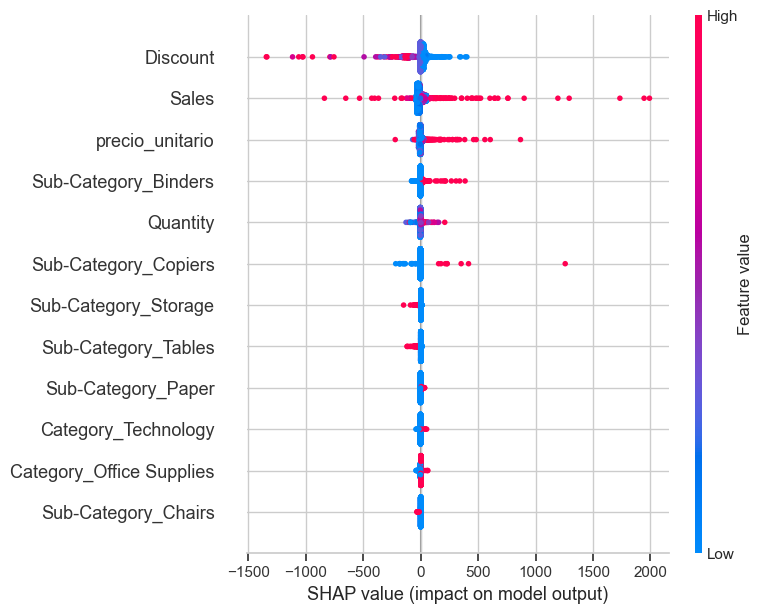

In [43]:
explainer = shap.TreeExplainer(xgb_best)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test, max_display=12)

Profit real: -3399.98 | Profit predicho: -2072.1
Category        Technology
Sub-Category      Machines
Sales             2549.985
Quantity                 5
Discount               0.7
Region                West
Name: 3011, dtype: object


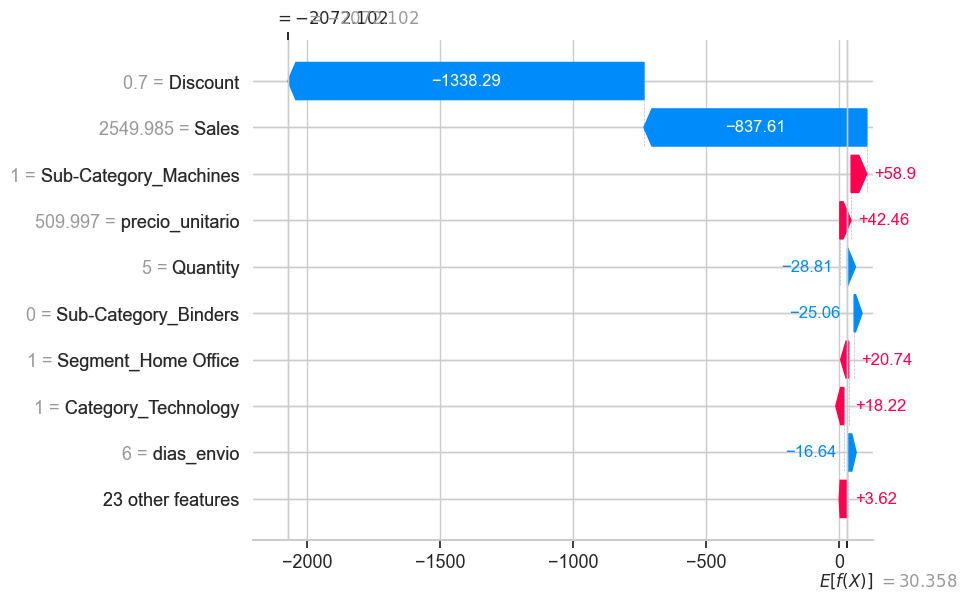

In [44]:
# Explicamos el pedido del test con la PEOR predicción de Profit (el caso que más interesa al negocio)
idx = int(np.argmin(xgb_best_preds))
print('Profit real:', round(y_test.iloc[idx], 2), '| Profit predicho:', round(float(xgb_best_preds[idx]), 2))
print(df.loc[X_test.index[idx], ['Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Region']])
shap.plots.waterfall(shap_values[idx], max_display=10)

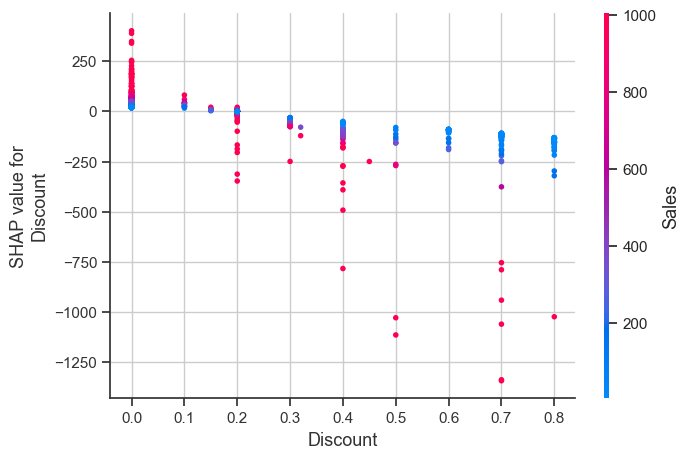

In [45]:
shap.dependence_plot('Discount', shap_values.values, X_test, interaction_index='Sales')

**✍️ Reflexión SHAP**

- **Visión global (summary plot):** `Discount` y `Sales` son las variables que más mueven la predicción. Los descuentos altos (puntos rojos) empujan el Profit hacia valores negativos. Las ventas altas amplían el efecto en los dos sentidos: un pedido grande puede dar mucho beneficio o mucha pérdida, según el descuento.
- **Pedido individual (waterfall):** analizamos el pedido con peor predicción del test, una máquina (*Technology → Machines*) con un 70 % de descuento. Su predicción parte del valor medio del Profit y el descuento por sí solo la hunde en miles de dólares. El importe alto de la venta amplifica el efecto. Es justo el tipo de pedido que habría que bloquear o revisar antes de aprobarlo.
- **Dependencia (dependence plot):** el efecto del descuento **no es lineal**. Hasta el 20 % su impacto es pequeño; a partir del 30 % la contribución SHAP cae de golpe. Y cuanto mayor es la venta (color), más fuerte es la caída. Esto confirma el umbral del EDA y del árbol de decisión.

---
## Fase 2.6 — Conclusión y Recomendaciones de Negocio

### Conclusiones técnicas

- **Clasificación (¿pérdida?):** la regresión logística detecta el 95 % de las líneas con pérdida (ROC-AUC ≈ 0,98). Se puede usar como alerta antes de cerrar una venta.
- **Regresión (¿cuánto beneficio?):** los ensembles de árboles superan con claridad al modelo lineal y al árbol individual. El mejor modelo es el **XGBoost ajustado con GridSearchCV**. El R² en test es moderado porque el Profit tiene colas extremas; el MAE indica un error típico de pocas decenas de dólares por línea.
- **Segmentación:** PCA + KMeans sobre 793 clientes da 4 segmentos interpretables. Los ejes principales son **rentabilidad** y **volumen**.
- **Explicabilidad:** SHAP, el árbol y el EDA coinciden en lo mismo: **el descuento por encima del 30 % es lo que más destruye beneficio**, y el efecto es mayor cuanto más grande es el pedido.

### Conclusión de negocio

1. **El problema no es vender poco, sino vender con demasiado descuento.** Las líneas con un 30 % o más de descuento restan ≈135.000 $, casi la mitad del beneficio total.
2. **El beneficio está muy concentrado.** El segmento *Rentables* aporta ≈86 % del beneficio, mientras que los *Destructores de margen* restan ≈24 %.
3. **Los productos que pierden dinero son pocos y concretos:** *Tables*, *Bookcases* y *Supplies*, sobre todo en la región Central y en estados como Texas, Ohio o Illinois.
4. Las relaciones son **no lineales y con efectos umbral**, así que los modelos simples no bastan para captarlas.

### Recomendaciones

1. **Poner un tope a los descuentos:** máximo 20 % sin aprobación, y más del 30 % solo con autorización expresa. Empezar por *Tables*, *Bookcases* y *Machines*.
2. **Usar el clasificador como alerta en el momento de la venta.** Si la probabilidad de pérdida es alta, el comercial o el sistema de pricing revisa el pedido antes de cerrarlo.
3. **Acciones distintas para cada segmento:**
   - *Rentables* → fidelización, programa premium y venta cruzada de Copiers, Phones y Accessories.
   - *Frecuentes con descuento* → bajar el descuento poco a poco a cambio de otras ventajas (envío, plazos).
   - *Ocasionales* → campañas de reactivación de bajo coste.
   - *Destructores de margen* → renegociar condiciones o subir precios; aceptar perder algo de volumen a cambio de margen.
4. **Revisar la región Central:** combina el descuento medio más alto con el peor margen.
5. **Medir por margen, no solo por ventas:** que los objetivos e incentivos comerciales incluyan el beneficio.
6. **Seguimiento continuo:** reentrenar los modelos cada trimestre y vigilar el % de líneas con pérdida y el descuento medio por segmento.